In [1]:
from src.model.MultiU_NetModel import MultiU_Net
from src.training.out_conv_training.SortingMethod import BEST_PERM
from src.model.MaskTransform import multi_class_post_process
from src.model.MaskVisualization import segmentation_visualizer


In [2]:
try:
    import kagglehub
except ImportError:
    !pip install kagglehub

import torch

from src.benchmark.ModelBenchmark import evaluate_model_on_dataset
from src.dataset.DroneSegDataSet import MyDataset
from src.dataset.CheckDataset import check_dataset
from torchvision import transforms

# 加载数据集
ds_path = check_dataset()
dataset = MyDataset(
    'drone_seg_dataset/classes_dataset/classes_dataset/original_images',
    'drone_seg_dataset/classes_dataset/classes_dataset/label_images_semantic',
    transform=transforms.Compose([
        transforms.ToTensor(),
    ]),
    # data_enforcement=True,
)

n_classes = 5
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


  Using cached kagglehub-1.0.0-py3-none-any.whl.metadata (40 kB)
  Using cached kagglesdk-0.1.19-py3-none-any.whl.metadata (13 kB)
Using cached kagglehub-1.0.0-py3-none-any.whl (70 kB)
Using cached kagglesdk-0.1.19-py3-none-any.whl (208 kB)
当前脚本路径: /home/jovyan/2026.3.25_BBC6521_DroneSegModel/src/dataset
项目根路径: /home/jovyan/2026.3.25_BBC6521_DroneSegModel
Dataset already exists.
成功匹配文件: 587.png, 326.png, 043.png 等 400 个文件


/opt/conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch.Size([3, 736, 960])
torch.Size([3, 736, 960])
torch.Size([3, 736, 960])
torch.Size([3, 736, 960])
torch.Size([3, 736, 960])


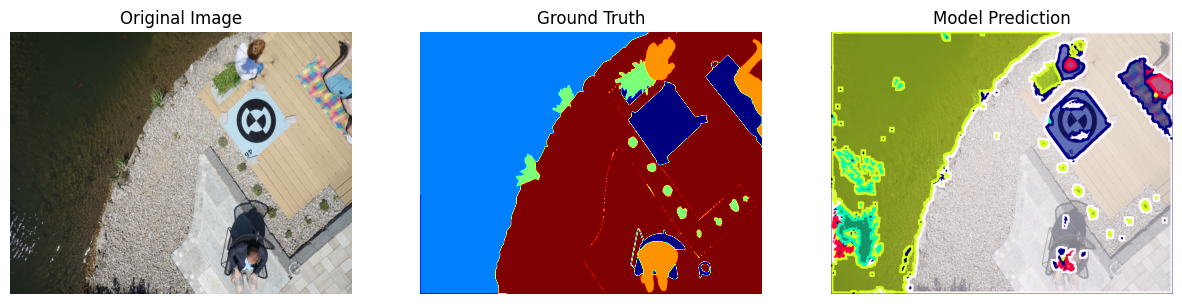

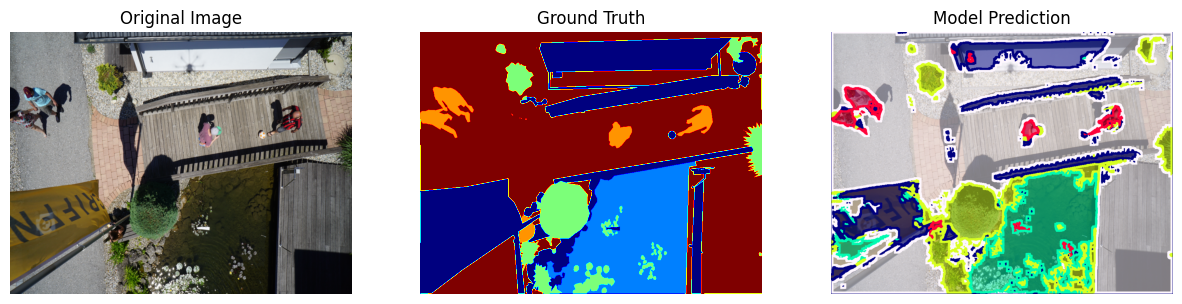

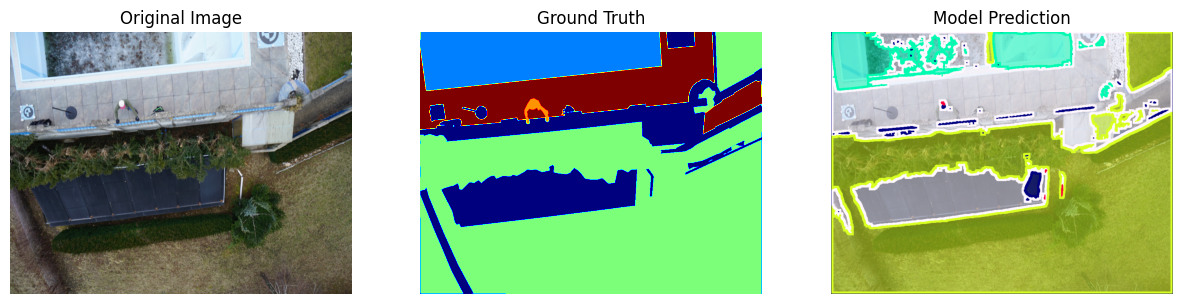

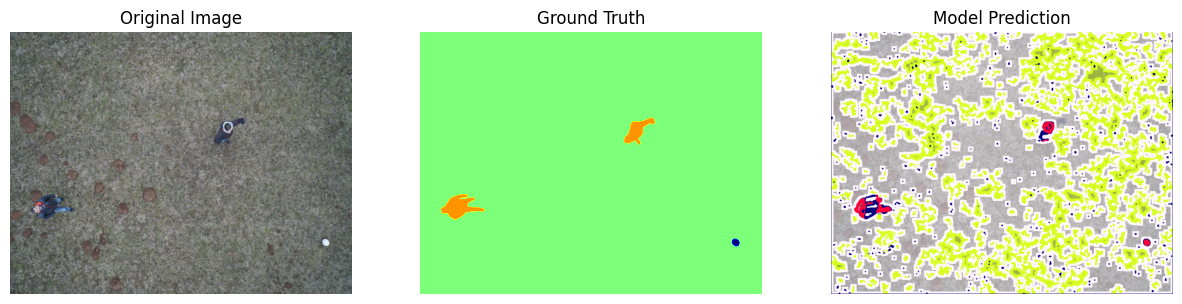

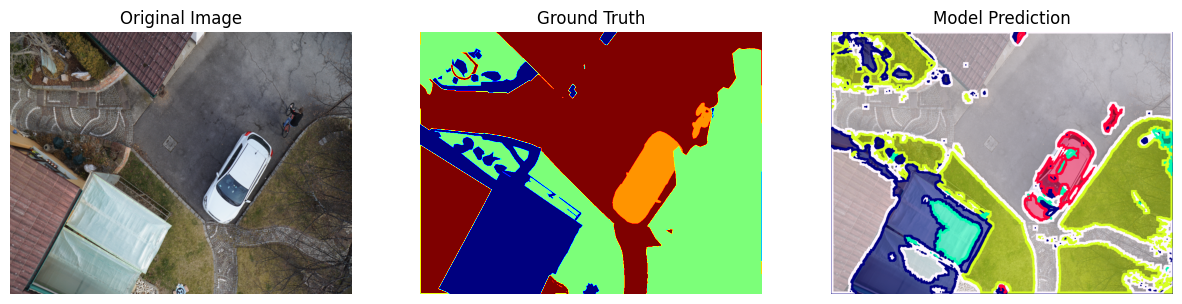

In [3]:
# 数据集大小400 随机获取5个样本的索引
import random
sample_indices = random.sample(range(len(dataset)), 5)

from src.model.MultiU_NetModel import MultiU_Net
model = MultiU_Net(
    in_channel=22,
    depth=[3] * 5,
    depthwise_separable=False,
    combine_method='out_layer',
).to(device)

import os
para_dir = 'resources/para'
para_list = [
    os.path.join(para_dir, 'unet_branch0.pth'),
    os.path.join(para_dir, 'unet_branch1.pth'),
    os.path.join(para_dir, 'unet_branch2.pth'),
    os.path.join(para_dir, 'unet_branch3.pth'),
    os.path.join(para_dir, 'unet_branch4.pth'),
]
out_para = os.path.join(para_dir, 'out_conv.pth')
model.read_param(para_list, out_para)

for idx in sample_indices:
    feat_img, label, img = dataset.__getitem__(idx)

    feat_img = feat_img.unsqueeze(0).to(device) # 添加批次维度
    with torch.no_grad():
        output = model(feat_img)

    fixed_output = multi_class_post_process(torch.argmax(output, dim=1), BEST_PERM)

    # 可视化
    print(img.shape)
    visualized = segmentation_visualizer(
        image=img.unsqueeze(0),
        mask=fixed_output.cpu(), # 去除批次维度
    )

    # 展示可视化的图片、原图、标签
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img.permute(1, 2, 0)) # 转换为 HWC 格式
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    axes[1].imshow(label.cpu(), cmap='jet', vmin=0, vmax=n_classes-1)
    axes[1].set_title('Ground Truth')
    axes[1].axis('off')

    axes[2].imshow(visualized)
    axes[2].set_title('Model Prediction')
    axes[2].axis('off')


In [4]:
# 遍历所有样本，检查哪些样本上表现最好，通过数据集中的文件名输出所有可以拿来展示的图片。

ans_list = []

from torch.utils.data import DataLoader
dataloader = DataLoader(dataset, batch_size=1, shuffle=False)

for batch_idx, (feat_img, label, img) in enumerate(dataloader):
    feat_img = feat_img.to(device)
    with torch.no_grad():
        output = model(feat_img)

    fixed_output = multi_class_post_process(torch.argmax(output, dim=1), BEST_PERM)

    # 检查正确率和miou

    def check_accuracy(pred, label):
        correct = (pred == label).sum().item()
        total = label.numel()
        return correct / total
    def check_miou(pred, label, n_classes):
        ious = []
        for cls in range(n_classes):
            pred_cls = (pred == cls)
            label_cls = (label == cls)
            intersection = (pred_cls & label_cls).sum().item()
            union = (pred_cls | label_cls).sum().item()
            if union > 0:
                ious.append(intersection / union)
        return sum(ious) / len(ious) if ious else 0

    acc = check_accuracy(fixed_output.cpu(), label.cpu())
    miou = check_miou(fixed_output.cpu(), label.cpu(), n_classes)

    file_name = dataset.get_file_name(batch_idx)

    ans_list.append((file_name, acc, miou))

# 按照准确率排序
ans_list.sort(key=lambda x: x[2], reverse=True)
# 输出前 40 个表现最好的图片名称
for i in range(40):
    print(ans_list[i][0], ans_list[i][1], ans_list[i][2])


314.png 0.9531603826992754 0.7969341185254051
342.png 0.8907820991847826 0.7249781141789391
391.png 0.9295926743659421 0.7244249712173402
309.png 0.909183933423913 0.7046033920256743
283.png 0.8983766417572464 0.6925669615247252
312.png 0.8653461843297101 0.6842479254506125
514.png 0.8725685009057971 0.6821057375076035
043.png 0.9147149569746377 0.6789402654024248
051.png 0.8890752377717391 0.67401565066291
281.png 0.9335626132246376 0.6619349416952984
251.png 0.9052493772644927 0.6605425665900435
228.png 0.8621320199275362 0.6580754140486836
424.png 0.8623485620471014 0.6544072398930791
014.png 0.8822435461956522 0.6532401026252788
460.png 0.8916312839673913 0.6518718434516826
070.png 0.8423743206521739 0.6506911650471697
558.png 0.8892861186594203 0.648166086357765
178.png 0.9090707087862319 0.6469082188847723
438.png 0.9240559895833333 0.6462003172501417
079.png 0.922063235960145 0.6459644483687643
532.png 0.8889237998188406 0.6422202399322711
252.png 0.8882968183876812 0.6420671786

In [4]:
# 遍历所有样本，检查哪些样本上表现最好，通过数据集中的文件名输出所有可以拿来展示的图片
# 只选择类别数量大于3的图片，并按miou排序取前40个

ans_list = []

from torch.utils.data import DataLoader
dataloader = DataLoader(dataset, batch_size=1, shuffle=False)

for batch_idx, (feat_img, label, img) in enumerate(dataloader):
    feat_img = feat_img.to(device)
    with torch.no_grad():
        output = model(feat_img)

    fixed_output = multi_class_post_process(torch.argmax(output, dim=1), BEST_PERM)

    # 计算标签中的类别数量
    unique_labels = torch.unique(label)
    num_classes_in_label = len(unique_labels)
    
    # 只处理类别数量大于3的图片
    if num_classes_in_label <= 3:
        continue

    # 检查准确率和miou
    def check_accuracy(pred, label):
        correct = (pred == label).sum().item()
        total = label.numel()
        return correct / total
    
    def check_miou(pred, label, n_classes):
        ious = []
        for cls in range(n_classes):
            pred_cls = (pred == cls)
            label_cls = (label == cls)
            intersection = (pred_cls & label_cls).sum().item()
            union = (pred_cls | label_cls).sum().item()
            if union > 0:
                ious.append(intersection / union)
        return sum(ious) / len(ious) if ious else 0

    acc = check_accuracy(fixed_output.cpu(), label.cpu())
    miou = check_miou(fixed_output.cpu(), label.cpu(), n_classes)

    file_name = dataset.get_file_name(batch_idx)

    ans_list.append((file_name, acc, miou, num_classes_in_label))

# 按照miou排序（降序）
ans_list.sort(key=lambda x: x[2], reverse=True)

print(f"总共找到 {len(ans_list)} 张类别数量大于3的图片")
print("前40张miou表现最好的图片：")

# 输出前 40 个表现最好的图片名称
for i in range(min(40, len(ans_list))):
    file_name, acc, miou, num_classes_count = ans_list[i]
    print(f"{i+1:2d}. {file_name} - Acc: {acc:.4f}, mIoU: {miou:.4f}, Classes: {num_classes_count}")

总共找到 369 张类别数量大于3的图片
前40张miou表现最好的图片：
 1. 596.png - Acc: 0.9358, mIoU: 0.7787, Classes: 4
 2. 314.png - Acc: 0.9441, mIoU: 0.7745, Classes: 4
 3. 424.png - Acc: 0.8763, mIoU: 0.7309, Classes: 5
 4. 004.png - Acc: 0.9232, mIoU: 0.7276, Classes: 4
 5. 051.png - Acc: 0.8959, mIoU: 0.7184, Classes: 5
 6. 312.png - Acc: 0.8910, mIoU: 0.7165, Classes: 5
 7. 514.png - Acc: 0.8775, mIoU: 0.7008, Classes: 5
 8. 251.png - Acc: 0.9074, mIoU: 0.6748, Classes: 5
 9. 283.png - Acc: 0.8956, mIoU: 0.6715, Classes: 5
10. 228.png - Acc: 0.8569, mIoU: 0.6671, Classes: 5
11. 342.png - Acc: 0.8682, mIoU: 0.6651, Classes: 5
12. 558.png - Acc: 0.9004, mIoU: 0.6638, Classes: 5
13. 126.png - Acc: 0.9028, mIoU: 0.6574, Classes: 5
14. 173.png - Acc: 0.8824, mIoU: 0.6566, Classes: 5
15. 043.png - Acc: 0.9041, mIoU: 0.6527, Classes: 4
16. 180.png - Acc: 0.9079, mIoU: 0.6516, Classes: 5
17. 583.png - Acc: 0.8819, mIoU: 0.6504, Classes: 5
18. 443.png - Acc: 0.8682, mIoU: 0.6500, Classes: 5
19. 016.png - Acc: 0.9047,